In [1]:
import numpy as np
from numpy import ndarray, int64
import torch

Firstly, we import the data from the data folder. For the task 1 we only want the first question, so we only take the labels of the first question. 

In [2]:
import os
from pathlib import Path
from galaxyzoo.data import load_data

img_path = Path("data/images")
labels_path = Path("data/labels.csv")

image_paths, labels_class = load_data(img_path, labels_path, task="task1")

## Preprocessing
Firstly, we will split the data into train, validation and test sets. 

In [3]:
from sklearn.model_selection import train_test_split

train_images, temp_images, train_labels, temp_labels = train_test_split(
    image_paths,
    labels_class,
    test_size=0.3,
    random_state=42,
    stratify=labels_class   #split to mantain the imbalance
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f'Training size: {len(train_labels)} ({len(train_labels)/len(labels_class)*100:.0f}%)')
print(f'Validation size: {len(val_labels)} ({len(val_labels)/len(labels_class)*100:.0f}%)')
print(f'Test size: {len(test_labels)} ({len(test_labels)/len(labels_class)*100:.0f}%)')

Training size: 43104 (70%)
Validation size: 9237 (15%)
Test size: 9237 (15%)


Next, we have to create a dataset for each set. We will use a different transformation for the training set, to increase the performance. 

In [4]:
from torchvision import transforms
from galaxyzoo.data import GalaxiesDataset

dim_pixels = 128
train_transform = transforms.Compose([
    transforms.CenterCrop(220), #cropping the image to zoom the galaxy
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.RandomHorizontalFlip(), #random rotation to improve the model
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(), #Normalize
])

validation_test_transform = transforms.Compose([
    transforms.CenterCrop(220), #cropping the image to zoom the galaxy
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.ToTensor(), #Normalize
])

train_dataset = GalaxiesDataset(train_images, train_labels, transform=train_transform)
validation_dataset = GalaxiesDataset(val_images, val_labels, transform=validation_test_transform)
test_dataset = GalaxiesDataset(test_images, test_labels, transform=validation_test_transform)

As the answers are imbalanced we have to use weights for training the model. 

In [5]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_labels)

#we add the weights as the data are imbalanced
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_labels
)

weights = torch.tensor(weights, dtype=torch.float32)

We plot the counts of every answer and also they weighted answer to validate the weights used. 

Text(0.5, 1.0, 'Answers classification weighted')

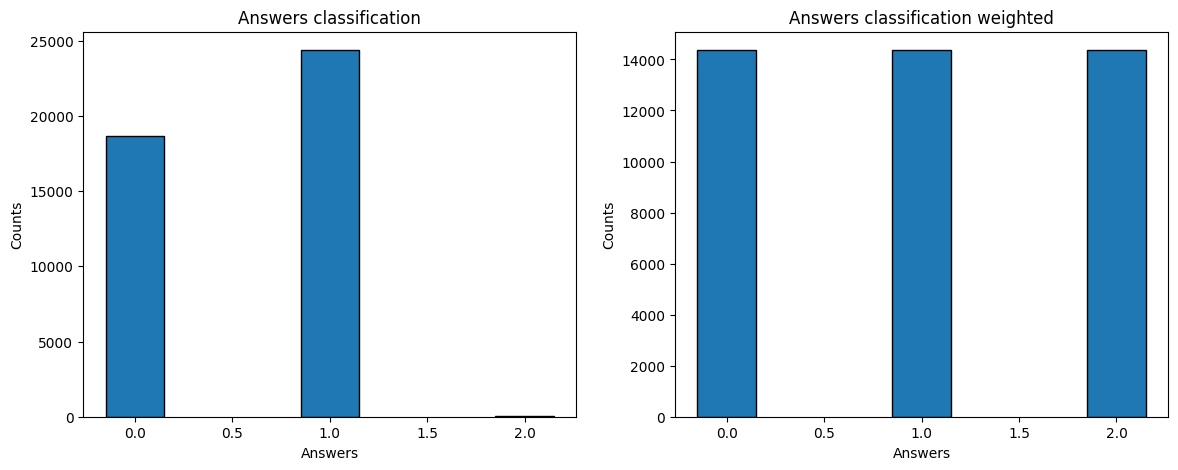

In [6]:
import matplotlib.pyplot as plt

labels_tensor = torch.tensor(train_labels)
counts = torch.bincount(labels_tensor)

#plot the figure
fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(14)

ax1 = plt.subplot(1,2,1)
ax1.bar([0,1,2], counts, width=0.3, edgecolor='k')
ax1.set_xlabel("Answers")
ax1.set_ylabel("Counts")
ax1.set_title('Answers classification')

ax2 = plt.subplot(1,2,2)
ax2.bar([0,1,2], counts*weights, width=0.3, edgecolor='k')
ax2.set_xlabel("Answers")
ax2.set_ylabel("Counts")
ax2.set_title('Answers classification weighted')

The weights are balancing the data, just what we want. 

Next, we will transform the dataset to dataloader of training, validation and test data. 

In [7]:
from torch.utils.data import DataLoader

batch_size=64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Training and fitting
After the preprocessing, we just need to specify the parameters of the model and fit the data. 

In [8]:
from torch import nn
from torch.optim import AdamW
from galaxyzoo.cnn import CNN
from galaxyzoo.training_utils import fit

in_channels = 3 #RGB
out_channels = 3 #3 answers

cnn_model = CNN(
    in_channels=in_channels,
    out_channels=out_channels,
    input_shape=(dim_pixels, dim_pixels),
    hidden_channels=16,
    final_hidden_channels=64,
    activation="relu",
)

cnn_optimizer = AdamW(cnn_model.parameters(), lr=5e-4, weight_decay=1e-4)
loss_function = nn.CrossEntropyLoss(weight=weights)
epochs = 15

train_losses, val_losses, train_accuracies, val_accuracies = fit(
    epochs=epochs,
    loss_function=loss_function,
    model=cnn_model,
    optimizer=cnn_optimizer,
    train_loader=train_loader,
    validation_loader=validation_loader,
    include_accuracy=True,
    task="classification"
)

-------------------------------
| Epoch 1                     |
| Train loss: 0.6724          |
| Validation loss: 0.6193     |
| Train accuracy: 73.50%      |
| Validation accuracy: 71.54% |
-------------------------------
-------------------------------
| Epoch 2                     |
| Train loss: 0.5746          |
| Validation loss: 0.5561     |
| Train accuracy: 75.21%      |
| Validation accuracy: 75.60% |
-------------------------------
-------------------------------
| Epoch 3                     |
| Train loss: 0.5504          |
| Validation loss: 0.5812     |
| Train accuracy: 76.17%      |
| Validation accuracy: 75.85% |
-------------------------------
-------------------------------
| Epoch 4                     |
| Train loss: 0.5559          |
| Validation loss: 0.5240     |
| Train accuracy: 75.85%      |
| Validation accuracy: 77.09% |
-------------------------------
-------------------------------
| Epoch 5                     |
| Train loss: 0.5352          |
| Valida

It is more useful to see the loss and the accuracy in a plot. 

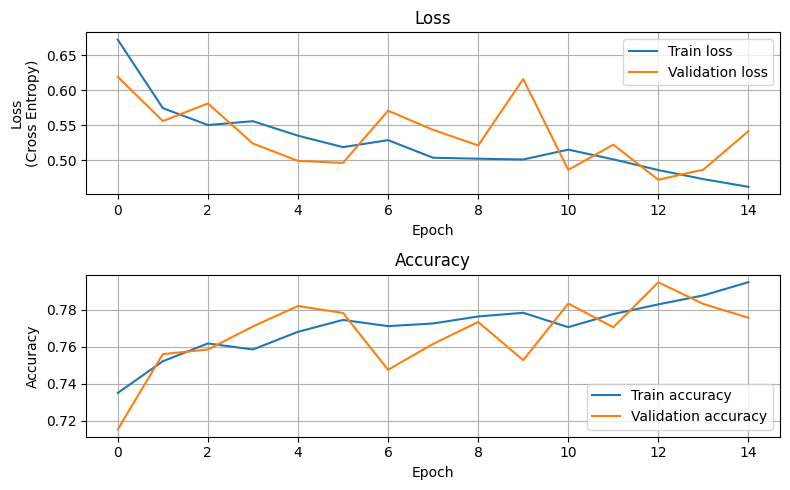

In [9]:
#plot the figure
fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(8)

ax1 = plt.subplot(2,1,1)
ax1.plot(train_losses, label="Train loss")
ax1.plot(val_losses, label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss\n(Cross Entropy)")
ax1.set_title("Loss")
ax1.legend()
ax1.grid()

ax2 = plt.subplot(2,1,2)
ax2.plot(train_accuracies, label="Train accuracy")
ax2.plot(val_accuracies, label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid()

plt.tight_layout()

## Evaluation
Finally, we will evaluate the model with the test data. We will compute the confusion matrix and the ROC curves. 

### Confusion matrix

In [10]:
import torch.nn.functional as F

labels_test = []
labels_preds = []
labels_probs = []

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = cnn_model(imgs)
        preds = torch.argmax(outputs, dim=1)
        probs = F.softmax(outputs, dim=1)

        labels_test.extend(labels.cpu().numpy())
        labels_preds.extend(preds.cpu().numpy())
        labels_probs.extend(probs.cpu().numpy())

Text(0.5, 1.0, 'Confusion Matrix')

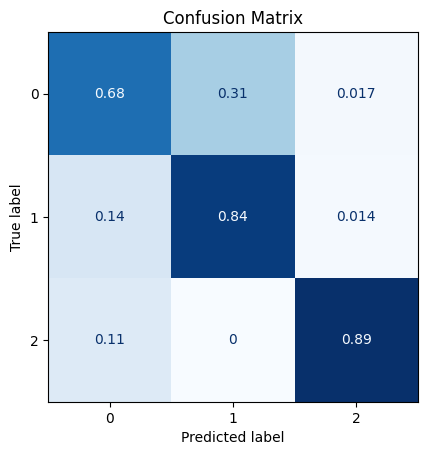

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#confusion matrix
cm = confusion_matrix(labels_test, labels_preds, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])

disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")

### ROC curves

Text(0.5, 1.0, 'ROC curves')

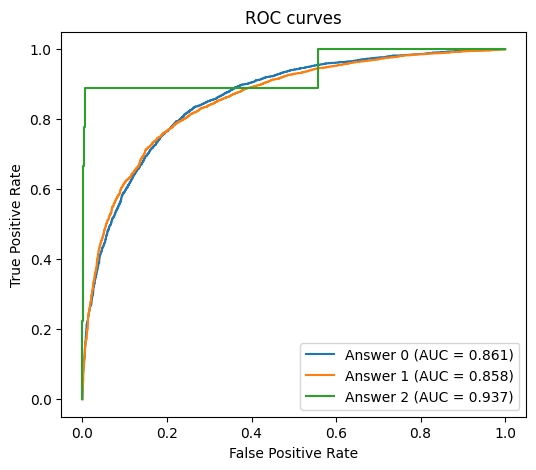

In [12]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

labels_test_bin = label_binarize(labels_test, classes=[0,1,2])
labels_probs = np.array(labels_probs)

#plot the figure
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(6)

for i in range(3):
    fpr, tpr, _ = roc_curve(labels_test_bin[:, i], labels_probs[:, i])
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label=f"Answer {i} (AUC = {roc_auc:.3f})")

ax.legend()
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves")